This notebook contains the gathering of the data into a comprehensive dataset for Homework 1.

In [43]:
# Import the necessary libraries
import os
import tabulate
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import sportsdataverse as sdv
import polars as pl
from great_tables import GT, md
from adjustText import adjust_text
from scipy import stats

In [55]:
# Load up play by play data and game data for the 2021-2025 seasons
# from the sportsdataverse library
plays_df_polars = sdv.cfb.load_cfb_pbp(seasons=[2021, 2022, 2023, 2024, 2025], return_as_pandas=False)

# Convert the polar files to pandas dataframes
pbp_2021_2025_raw = plays_df_polars.to_pandas(use_pyarrow_extension_array=False)

In [56]:
# examine the shape of the play by play data
pbp_2021_2025_raw.shape

(778447, 477)

In [57]:
# Examine the available columns of the play by play data
col_list = pbp_2021_2025_raw.columns.tolist()
pd.set_option('display.max_seq_items', None)
print("\n".join(pbp_2021_2025_raw.columns))

season
game_id
game_play_number
pos_team_id
pos_team
def_pos_team_id
def_pos_team
pos_team_score
def_pos_team_score
half
period
down
distance
EPA
wpa
wp_before
wp_after
def_wp_before
def_wp_after
penalty_detail
yds_penalty
penalty_1st_conv
def_EPA
rz_play
scoring_opp
middle_8
stuffed_run
change_of_pos_team
downs_turnover
pos_score_diff_start
pos_score_pts
home_wp_before
away_wp_before
home_wp_after
away_wp_after
end_of_half
lead_pos_team
lead_play_type
lag_pos_team
orig_play_type
offense_score_play
defense_score_play
pos_score_diff
change_of_poss
rusher_player_name
yds_rushed
passer_player_name
receiver_player_name
yds_receiving
yds_sacked
sack_players
sack_player_name
sack_player_name2
pass_breakup_player_name
interception_player_name
yds_int_return
fumble_player_name
fumble_forced_player_name
fumble_recovered_player_name
yds_fumble_return
punter_player_name
yds_punted
yds_punt_return
yds_punt_gained
punt_block_player_name
punt_block_return_player_name
fg_kicker_player_name
yds_fg
fg_

In [58]:
# explore values of the orig_play_type column
pbp_2021_2025_raw['pass'].value_counts()

pass
False    484584
True     293863
Name: count, dtype: int64

In [59]:
# explore values of the seasonType column
pbp_2021_2025_raw['seasonType'].value_counts()

seasonType
2    739858
3     37573
4      1016
Name: count, dtype: int64

During the filtering process, I will filter out the following:

- Regular season only
- There is a valid possesion team (not na)
- The play type is a pass or a run
- epa is not null
- wpa is not null
- filter for only power 4 conferences (ACC, Big 12, Big 10, SEC)


Note: as seen above, the seasonType column has a few categories. 

According to the SportsDataVerse website: 

2 = regular season
3 = post season.

However, it does not say anything about 4. Since we will filter for 2, all 4's will be filtered out. I am quite sure that the rows with 4 are errors of some kind.

Here is the link I used to find this information:
https://py.sportsdataverse.org/docs/cfb/reference/loaders



NOTE:

It seems that this data does not include the conference of the school. 

To tackle this I will make a list of power 4 schools and filter out and possession team that is not in this list.

In [ ]:
# create list of power 4 teams so that later we can filter out non power 4 teams from the play by play data
power4_teams = [
    'Nebraska Cornhuskers', 'Illinois Fighting Illini',
       'Minnesota Golden Gophers', 'Ohio State Buckeyes',
       'NC State Wolfpack', 'Tennessee Volunteers',
       'Virginia Tech Hokies', 'North Carolina Tar Heels',
       'Duke Blue Devils', 'Kansas Jayhawks', 'Michigan State Spartans',
       'Northwestern Wildcats', 'Alabama Crimson Tide',
       'Miami Hurricanes', 'Oklahoma Sooners', 'Georgia Bulldogs', 'Clemson Tigers', 'Texas A&M Aggies', 
       'Iowa State Cyclones', 'Penn State Nittany Lions',
       'Wisconsin Badgers', 'Florida Gators', 'Notre Dame Fighting Irish', 'Iowa Hawkeyes', 'Indiana Hoosiers', 'Texas Longhorns', 'Kentucky Wildcats',
       'Boston College Eagles', 'Michigan Wolverines', 'Rutgers Scarlet Knights', 'Stanford Cardinal', 'Kansas State Wildcats',
       'Maryland Terrapins', 'West Virginia Mountaineers',
       'Mississippi State Bulldogs', 'Missouri Tigers', 'Auburn Tigers', 'South Carolina Gamecocks',
       'Purdue Boilermakers', 'Houston Cougars', 'Texas Tech Red Raiders', 'Oklahoma State Cowboys', 'Baylor Bears',
       'Virginia Cavaliers', 'UCLA Bruins',
       'LSU Tigers', 'Florida State Seminoles', 'Ole Miss Rebels',
       'Louisville Cardinals', 'Oregon Ducks', 'Arkansas Razorbacks', 'Pittsburgh Panthers', 'Georgia Tech Yellow Jackets',
       'Wake Forest Demon Deacons', 'Syracuse Orange', 'Colorado Buffaloes', 'California Golden Bears', 'TCU Horned Frogs', 
       'Washington Huskies', 'Vanderbilt Commodores', 'UCF Knights', 'Cincinnati Bearcats', 'SMU Mustangs', 'BYU Cougars',
       'Utah Utes', 'Arizona State Sun Devils', 'Arizona Wildcats', 'USC Trojans'
       ]

In [ ]:
# Filter the data to include only regular season plays,
# valid possession team,
# pass or run plays only,
# power 4 conferences only(ACC, Big 12, Big 10, SEC)
# and valid EPA and WPA values
pbp_filtered = pbp_2021_2025_raw[
    (pbp_2021_2025_raw['seasonType'] == 2) &
    (pbp_2021_2025_raw['pos_team'].notna()) &
    ((pbp_2021_2025_raw['pass'] == True) | (pbp_2021_2025_raw['rush'] == True)) &
    (pbp_2021_2025_raw['EPA'].notna()) &
    (pbp_2021_2025_raw['wpa'].notna()) &
    (pbp_2021_2025_raw['pos_team'].isin(power4_teams))
].copy()

Now, let's check up on the seasonType value to make sure.

In [69]:
# check the seasonType values in the filtered data
pbp_filtered['seasonType'].sort_values(ascending=False)

770205    2
1         2
2         2
3         2
4         2
         ..
22        2
21        2
20        2
19        2
18        2
Name: seasonType, Length: 271854, dtype: int64

In [70]:
# Check the shape of the filtered data
pbp_filtered.shape

(271854, 477)

In [ ]:
# examine the available columns of the filtered play by play data
pbp_filtered.columns

Index(['season', 'game_id', 'game_play_number', 'pos_team_id', 'pos_team',
       'def_pos_team_id', 'def_pos_team', 'pos_team_score',
       'def_pos_team_score', 'half', 'period', 'down', 'distance', 'EPA',
       'wpa', 'wp_before', 'wp_after', 'def_wp_before', 'def_wp_after',
       'penalty_detail', 'yds_penalty', 'penalty_1st_conv', 'def_EPA',
       'rz_play', 'scoring_opp', 'middle_8', 'stuffed_run',
       'change_of_pos_team', 'downs_turnover', 'pos_score_diff_start',
       'pos_score_pts', 'home_wp_before', 'away_wp_before', 'home_wp_after',
       'away_wp_after', 'end_of_half', 'lead_pos_team', 'lead_play_type',
       'lag_pos_team', 'orig_play_type', 'offense_score_play',
       'defense_score_play', 'pos_score_diff', 'change_of_poss',
       'rusher_player_name', 'yds_rushed', 'passer_player_name',
       'receiver_player_name', 'yds_receiving', 'yds_sacked', 'sack_players',
       'sack_player_name', 'sack_player_name2', 'pass_breakup_player_name',
       'interceptio

Now, let's get rid of the columns we dont want.

Since we are only looking at offense, let's look keep only the following:
- 'pass'
- 'rush'
- 'EPA',
- 'wpa'
- 'yds_rushed'
- 'yds_receiving'
- 'pass_attempt'/ 'completion'
- 'statYardage'
- 'air_yards'
- 'yards_after_catch'
- 'new_down'
- 'adj_rush_yardage'
- 'line_yards'
- 'second_level_yards'
- 'open_field_yards'
- 'highlight_yards'
- 'EPA_rush'
- 'EPA_pass'
- 'EPA_scrimmage'
- 'drive_offense_plays'
- 'prog_drive_EPA'
- 'prog_drive_WPA'
- 'drive_offense_yards'
- 'pass_epa'
- 'rush_epa'
- 'EPA_success'

We will also need to keep attributes that identify the row and can be used for grouping/ aggregation.

The following columns will also be kept:
- 'season'
- 'week'
- 'pos_team'

In [71]:
# keep only necessary columns for analysis
pbp_filtered = pbp_filtered[['season', 'week', 'pos_team','pass','rush','EPA',
'wpa',
'yds_rushed',
'yds_receiving',
'pass_attempt',
'completion',
'statYardage',
'air_yards',
'yards_after_catch',
'new_down',
'adj_rush_yardage',
'line_yards',
'second_level_yards',
'open_field_yards',
'highlight_yards',
'EPA_rush',
'EPA_pass',
'EPA_scrimmage',
'drive_offense_plays',
'prog_drive_EPA',
'prog_drive_WPA',
'drive_offense_yards',
'pass_epa',
'rush_epa', 'EPA_success']]

In [72]:
# Aggregate the Weekly Offensive Metrics so that we can split season into equal halves in the next cell
weekly_offense = (
    pbp_filtered.groupby(['season', 'week', 'pos_team'])
    .apply(
        lambda x: pd.Series({
            'off_plays': len(x),
            'off_epa_per_play': x['EPA'].mean(),
            'off_pass_epa': x.loc[x['pass'] == 1, 'EPA'].mean(),
            'off_rush_epa': x.loc[x['rush'] == 1, 'EPA'].mean(),
            'off_success_rate': x['EPA_success'].mean(),
            'pass_rate': (x['pass'] == 1).mean(),
            'complete_pass_pct': x['completion'].mean()
        }),
        include_groups=False
    )
    .reset_index()
)

In [73]:
# split the season into two havles for analysis
# create a column to define the half of the season based on the week number
weekly_offense['half_season'] = np.where(weekly_offense['week'] <= 9, "H1", "H2")

# Aggregate the Weekly Offensive Metrics by season, team, and half season
halfseason_team_panel = (
    weekly_offense.groupby(['pos_team', 'half_season'])
    .agg(
        mean_off_plays=('off_plays', 'mean'),
        mean_off_epa_per_play=('off_epa_per_play', 'mean'),
        mean_off_pass_epa=('off_pass_epa', 'mean'),
        mean_off_rush_epa=('off_rush_epa', 'mean'),
        mean_off_success_rate=('off_success_rate', 'mean'),
        mean_pass_rate=('pass_rate', 'mean'),
        mean_complete_pass_pct=('complete_pass_pct', 'mean')
    )
    .reset_index()
)

In [82]:
# check the value counts so that there are only 2 per team (one for each half of the season)
halfseason_team_panel['pos_team'].value_counts().sort_values(ascending=False)

pos_team
Alabama Crimson Tide          2
Arizona State Sun Devils      2
Arizona Wildcats              2
Arkansas Razorbacks           2
Auburn Tigers                 2
                             ..
Virginia Tech Hokies          2
Wake Forest Demon Deacons     2
Washington Huskies            2
West Virginia Mountaineers    2
Wisconsin Badgers             2
Name: count, Length: 68, dtype: int64

In [ ]:
# Pivot to a wide format such that h1 vs h2 metrics can be compared for each team
metrics_wide = halfseason_team_panel.pivot(index='pos_team', columns='half_season')
metrics_wide.columns = [f"{val}_{stat}" for val, stat in metrics_wide.columns]
metrics_wide = metrics_wide.reset_index()

In [ ]:
# Look at the metrics dataframe to confirm that the operations above worked as expected
metrics_wide

,pos_team,mean_off_plays_H1,mean_off_plays_H2,mean_off_epa_per_play_H1,mean_off_epa_per_play_H2,mean_off_pass_epa_H1,mean_off_pass_epa_H2,mean_off_rush_epa_H1,mean_off_rush_epa_H2,mean_off_success_rate_H1,mean_off_success_rate_H2,mean_pass_rate_H1,mean_pass_rate_H2,mean_complete_pass_pct_H1,mean_complete_pass_pct_H2
0,Alabama Crimson Tide,66.900000,69.652174,0.193011,0.152291,0.274155,0.230622,0.106231,0.065810,0.477748,0.482021,0.492494,0.501338,0.304404,0.296734
1,Arizona State Sun Devils,67.083333,64.818182,0.102155,0.090248,0.064620,0.037562,0.145424,0.149887,0.463695,0.449060,0.499475,0.461834,0.285039,0.260282
2,Arizona Wildcats,67.564103,65.571429,0.067027,0.073549,0.048959,0.121567,0.079075,-0.019381,0.465850,0.431585,0.570062,0.557081,0.341390,0.323984
3,Arkansas Razorbacks,69.102564,66.750000,0.163451,0.031609,0.191175,0.046974,0.142196,0.025829,0.484969,0.443526,0.453290,0.476982,0.263614,0.270505
4,Auburn Tigers,65.625000,66.300000,0.079028,0.058717,0.041257,-0.071262,0.103202,0.152876,0.459545,0.434783,0.470582,0.478751,0.260950,0.251329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,Virginia Tech Hokies,65.410256,60.947368,0.017051,-0.007349,0.033515,-0.072924,0.018073,0.047436,0.425305,0.414597,0.476521,0.425971,0.255271,0.208760
64,Wake Forest Demon Deacons,70.289474,71.619048,0.076496,0.077394,0.127115,0.067365,0.027336,0.052072,0.446498,0.449465,0.501405,0.510964,0.282155,0.276926
65,Washington Huskies,66.375000,64.380952,0.195298,0.103173,0.307602,0.084974,0.054442,0.114512,0.512579,0.474891,0.553292,0.548146,0.362204,0.324542
66,West Virginia Mountaineers,70.615385,68.850000,0.064099,0.013860,0.071251,-0.003155,0.047507,-0.001068,0.445096,0.426174,0.460701,0.459113,0.264973,0.242237


In [ ]:
# Create a list of metrics to analyze for the loop below
metric_list = [
    'mean_off_plays', 'mean_off_epa_per_play', 'mean_off_pass_epa', 'mean_off_rush_epa', 'mean_off_success_rate', 'mean_pass_rate', 'mean_complete_pass_pct'
]

# Compute Pearson r, p-value, and R-squared
corr_data = []

for m in metric_list:
    col_h1 = f"{m}_H1"
    col_h2 = f"{m}_H2"
    
    valid_data = metrics_wide[[col_h1, col_h2]].dropna()
    r, p_val = stats.pearsonr(valid_data[col_h1], valid_data[col_h2])
    
    corr_data.append({
        'metric': m,
        'r': r,
        'p_value': p_val,
        'r_squared': r ** 2
    })

correlation_results = pd.DataFrame(corr_data).sort_values(by='r', ascending=False)

In [ ]:
# Create a formatted table using great_tables to display the correlation results
GT(correlation_results).tab_header(
    title="2025 NFL Offense Split-Half Reliability",
    subtitle="Pearson Correlation (r) between Weeks 1-9 (H1) and Weeks 10-18 (H2)"
).cols_label(
    metric="Offensive Metric",
    r="Pearson r",
    p_value="p-value",
    r_squared="R²"
).fmt_number(
    columns=["r", "p_value", "r_squared"], 
    decimals=3
)

GT(_tbl_data=                   metric         r       p_value  r_squared
5          mean_pass_rate  0.828014  3.063264e-18   0.685608
6  mean_complete_pass_pct  0.773774  1.026287e-14   0.598726
4   mean_off_success_rate  0.747797  2.354021e-13   0.559200
1   mean_off_epa_per_play  0.703308  2.269120e-11   0.494642
0          mean_off_plays  0.669478  4.325446e-10   0.448200
2       mean_off_pass_epa  0.615541  2.322105e-08   0.378891
3       mean_off_rush_epa  0.577533  2.520143e-07   0.333545, _body=<great_tables._gt_data.Body object at 0x000001A5F594A180>, _boxhead=Boxhead([ColInfo(var='metric', type=<ColInfoTypeEnum.default: 1>, column_label='Offensive Metric', column_align='left', column_width=None), ColInfo(var='r', type=<ColInfoTypeEnum.default: 1>, column_label='Pearson r', column_align='right', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='r_squared', type=<ColInfoTypeEnum.default: 1>, column_label='R²', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001A5F5959BB0>, _spanners=Spanners([]), _heading=Heading(title='2025 NFL Offense Split-Half Reliability', subtitle='Pearson Correlation (r) between Weeks 1-9 (H1) and Weeks 10-18 (H2)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001A5F5959CA0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001A5F5959E20>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000001A5F595A300>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000001A5F5ACD8E0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid')

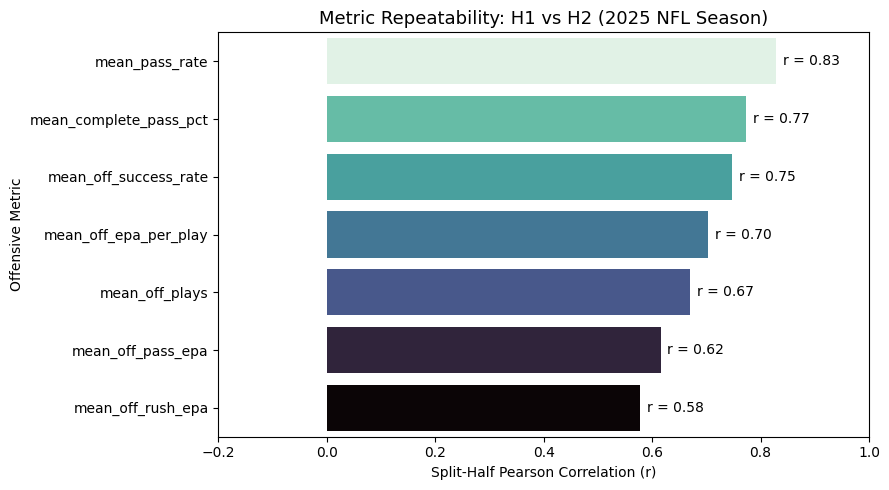

In [ ]:
# Create a visualization of the results from the table above
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=correlation_results,
    x='r',
    y='metric',
    palette='mako',
    hue='r',
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"r = {width:.2f}",
        (width, p.get_y() + p.get_height() / 2.),
        ha='left', va='center',
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=10
    )

plt.xlim(-0.2, 1.0)
plt.title("Metric Repeatability: H1 vs H2 (2025 NFL Season)", fontsize=13)
plt.xlabel("Split-Half Pearson Correlation (r)")
plt.ylabel("Offensive Metric")
plt.tight_layout()
plt.show()

According to the comprehensive data from the 2021-2025 cfb seasons, the top 3 best offensive metrics were 'mean_pass_rate', 'mean_complete_pass_pct' and 'mean_off_success_rate'.

However, lets' compare individual years and compare them as well.